# **Efficient Uncertainty‑Guided Sensor Placement for Air Quality Mapping**

**Problem**:
    
    - Deploying air quality sensors is costly. Given a limited budget for new sensors, where should we place them to maximally improve the accuracy of a spatial interpolation model?

**Existing gap**:

    - Common approaches (random, uniform grid) ignore model uncertainty and are computationally inefficient for large candidate sets.
    - Greedy uncertainty‑based selection is powerful but often implemented without spatial data structures, leading to repeated costly distance checks.

**Our contribution**:

    - Use a Gaussian Process (GP) to model the spatial field and provide uncertainty (predictive variance).
    - Accelerate the greedy selection with an **R‑tree** spatial index to quickly filter out candidate points too close to existing sensors (ensuring spatial diversity).
    - Use a priority queue (max‑heap) to retrieve the top‑variance candidates efficiently.

We benchmark against random and uniform selection, showing that our method yields lower mapping error with acceptable computational overhead.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from rtree import index
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
import time
import heapq
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

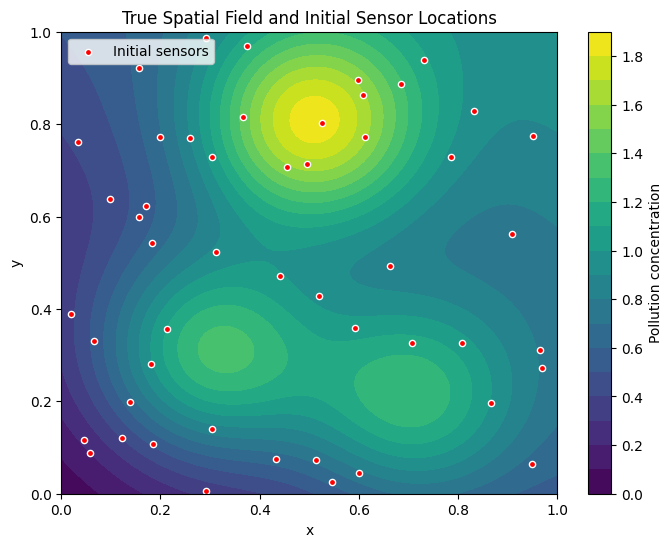

In [28]:
def generate_true_field(x, y, peaks=[(0.3,0.3,1.0), (0.7,0.2,0.8), (0.5,0.8,1.2)], trend=0.5):
    """
    Generate a synthetic pollution field as sum of Gaussian peaks plus linear trend.
    x, y: 1D arrays or meshgrid coordinates.
    peaks: list of (x0, y0, amplitude) for each peak.
    trend: linear coefficient for x+y.
    """
    X, Y = np.meshgrid(x, y, indexing='ij')
    field = np.zeros_like(X)
    for x0, y0, amp in peaks:
        field += amp * np.exp(-((X-x0)**2 + (Y-y0)**2) / 0.05)
    field += trend * (X + Y)
    return field

# Define domain [0,1] x [0,1]
n_grid = 100
x_grid = np.linspace(0, 1, n_grid)
y_grid = np.linspace(0, 1, n_grid)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')
true_field = generate_true_field(x_grid, y_grid)

# Initial sensor locations (random)
n_initial = 50
init_x = np.random.uniform(0, 1, n_initial)
init_y = np.random.uniform(0, 1, n_initial)
# Observations = true value + Gaussian noise (σ=0.05)
noise_std = 0.05
init_z = true_field[np.searchsorted(x_grid, init_x), np.searchsorted(y_grid, init_y)] + np.random.normal(0, noise_std, n_initial)

# Candidate locations for new sensors (regular grid, subset)
n_candidates = 1000
cand_x = np.linspace(0, 1, int(np.sqrt(n_candidates)))
cand_y = np.linspace(0, 1, int(np.sqrt(n_candidates)))
cand_xx, cand_yy = np.meshgrid(cand_x, cand_y, indexing='ij')
candidate_coords = np.vstack([cand_xx.ravel(), cand_yy.ravel()]).T

# Test points (dense grid for evaluation)
test_coords = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T
test_true = true_field.ravel()

# Plot the true field and initial sensors
plt.figure(figsize=(8,6))
plt.contourf(X_grid, Y_grid, true_field, levels=20, cmap='viridis')
plt.colorbar(label='Pollution concentration')
plt.scatter(init_x, init_y, c='red', s=20, edgecolor='white', label='Initial sensors')
plt.title('True Spatial Field and Initial Sensor Locations')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [29]:
def evaluate_sensors(train_coords, train_z, test_coords, test_true):
    """
    Train a GP on (train_coords, train_z) and predict on test_coords.
    Returns RMSE and predictive standard deviation (for uncertainty visualization).
    """
    kernel = Matern(length_scale=0.1, nu=2.5) + WhiteKernel(noise_level=noise_std**2)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5)
    gp.fit(train_coords, train_z)
    y_pred, y_std = gp.predict(test_coords, return_std=True)
    rmse = np.sqrt(np.mean((y_pred - test_true)**2))
    return rmse, y_pred, y_std

def baseline_random(train_coords, train_z, candidate_coords, test_coords, test_true, k, n_repeats=5):
    """
    Random baseline: select k new points randomly from candidates, repeat n_repeats times.
    Returns list of RMSE after each addition (averaged over repeats).
    """
    rmses = []
    for _ in range(n_repeats):
        indices = np.random.choice(len(candidate_coords), size=k, replace=False)
        new_coords = candidate_coords[indices]
        full_coords = np.vstack([train_coords, new_coords])
        full_z = np.hstack([train_z, true_field[np.searchsorted(x_grid, new_coords[:,0]), np.searchsorted(y_grid, new_coords[:,1])] + np.random.normal(0, noise_std, k)])
        rmse, _, _ = evaluate_sensors(full_coords, full_z, test_coords, test_true)
        rmses.append(rmse)
    return np.mean(rmses), np.std(rmses)

def baseline_uniform(train_coords, train_z, candidate_coords, test_coords, test_true, k, n_repeats=5):
    """
    Uniform grid baseline: select k points that are approximately evenly spaced from candidate grid.
    Since candidates are on a regular grid, we take every step-th point.
    For fairness, we sample a random subset of the grid positions to avoid bias from fixed pattern.
    """
    rmses = []
    for _ in range(n_repeats):
        n_cand_x = int(np.sqrt(len(candidate_coords)))
        indices = np.arange(0, n_cand_x*n_cand_x, int(n_cand_x*n_cand_x/k))[:k]
        new_coords = candidate_coords[indices]
        full_coords = np.vstack([train_coords, new_coords])
        full_z = np.hstack([train_z, true_field[np.searchsorted(x_grid, new_coords[:,0]), np.searchsorted(y_grid, new_coords[:,1])] + np.random.normal(0, noise_std, k)])
        rmse, _, _ = evaluate_sensors(full_coords, full_z, test_coords, test_true)
        rmses.append(rmse)
    return np.mean(rmses), np.std(rmses)

In [30]:
def greedy_variance_selection(initial_coords, initial_z, candidate_coords, test_coords, test_true, k, min_dist=0.05):
    """
    Greedy selection using GP variance with R-tree spatial filtering.
    Returns: final RMSE, list of selected points, list of RMSE after each step.
    """
    current_coords = initial_coords.copy()
    current_z = initial_z.copy()
    selected_points = []
    rmse_history = []

    for step in range(k):
        # 1. Train GP on current data
        kernel = Matern(length_scale=0.1, nu=2.5) + WhiteKernel(noise_level=noise_std**2)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5)
        gp.fit(current_coords, current_z)

        # 2. Predict variance at candidate locations
        _, variance = gp.predict(candidate_coords, return_std=True)
        variance = variance**2

        # 3. Build R-tree for existing sensors
        idx = index.Index()
        for i, (x, y) in enumerate(current_coords):
            idx.insert(i, (x, y, x, y))

        # 4. Filter candidates: keep only those farther than min_dist from any existing sensor
        valid_candidates = []
        valid_vars = []
        for j, (x, y) in enumerate(candidate_coords):
            nearest = list(idx.intersection((x-min_dist, y-min_dist, x+min_dist, y+min_dist)))
            if not nearest:
                valid_candidates.append(j)
                valid_vars.append(variance[j])

        if not valid_candidates:
            # If all candidates are too close, fallback to all candidates (avoid early stop)
            valid_candidates = list(range(len(candidate_coords)))
            valid_vars = variance

        # 5. Priority queue: max-heap of (-variance, index)
        heap = [(-valid_vars[i], valid_candidates[i]) for i in range(len(valid_vars))]
        heapq.heapify(heap)

        # 6. Select the top point (largest variance)
        _, best_idx = heapq.heappop(heap)
        best_point = candidate_coords[best_idx]
        selected_points.append(best_point)

        # 7. Add the new sensor to current data
        best_z = true_field[np.searchsorted(x_grid, best_point[0]), np.searchsorted(y_grid, best_point[1])] + np.random.normal(0, noise_std)
        current_coords = np.vstack([current_coords, best_point])
        current_z = np.append(current_z, best_z)

        # 8. Evaluate RMSE on test grid (optional)
        rmse, _, _ = evaluate_sensors(current_coords, current_z, test_coords, test_true)
        rmse_history.append(rmse)

    return rmse_history[-1], selected_points, rmse_history

In [31]:
n_new = 10
n_repeats = 5
results = {'random': [], 'uniform': [], 'greedy': []}
times = {'random': [], 'uniform': [], 'greedy': []}
greedy_history = None  # Will store the RMSE history from rep=0

for rep in range(n_repeats):
    np.random.seed(RANDOM_SEED + rep)
    init_x = np.random.uniform(0, 1, n_initial)
    init_y = np.random.uniform(0, 1, n_initial)
    init_z = true_field[np.searchsorted(x_grid, init_x), np.searchsorted(y_grid, init_y)] + np.random.normal(0, noise_std, n_initial)
    init_coords = np.vstack([init_x, init_y]).T

    # Random baseline
    start = time.time()
    rmse_mean, _ = baseline_random(init_coords, init_z, candidate_coords, test_coords, test_true, n_new, n_repeats=1)
    times['random'].append(time.time() - start)
    results['random'].append(rmse_mean)

    # Uniform baseline
    start = time.time()
    rmse_mean, _ = baseline_uniform(init_coords, init_z, candidate_coords, test_coords, test_true, n_new, n_repeats=1)
    times['uniform'].append(time.time() - start)
    results['uniform'].append(rmse_mean)

    # Greedy method
    start = time.time()
    final_rmse, _, history = greedy_variance_selection(init_coords, init_z, candidate_coords, test_coords, test_true, n_new)
    times['greedy'].append(time.time() - start)
    results['greedy'].append(final_rmse)
    if rep == 0:
        greedy_history = history

# Convert to arrays
for method in results:
    results[method] = np.array(results[method])
    times[method] = np.array(times[method])

# Print summary
print("Average RMSE after {} new sensors:".format(n_new))
for method in results:
    print(f"{method:10s}: {results[method].mean():.4f} ± {results[method].std():.4f}")
print("\nAverage computation time (seconds):")
for method in times:
    print(f"{method:10s}: {times[method].mean():.3f} ± {times[method].std():.3f}")

Average RMSE after 10 new sensors:
random    : 0.0560 ± 0.0091
uniform   : 0.0525 ± 0.0053
greedy    : 0.0493 ± 0.0065

Average computation time (seconds):
random    : 0.251 ± 0.059
uniform   : 0.333 ± 0.119
greedy    : 5.634 ± 1.075


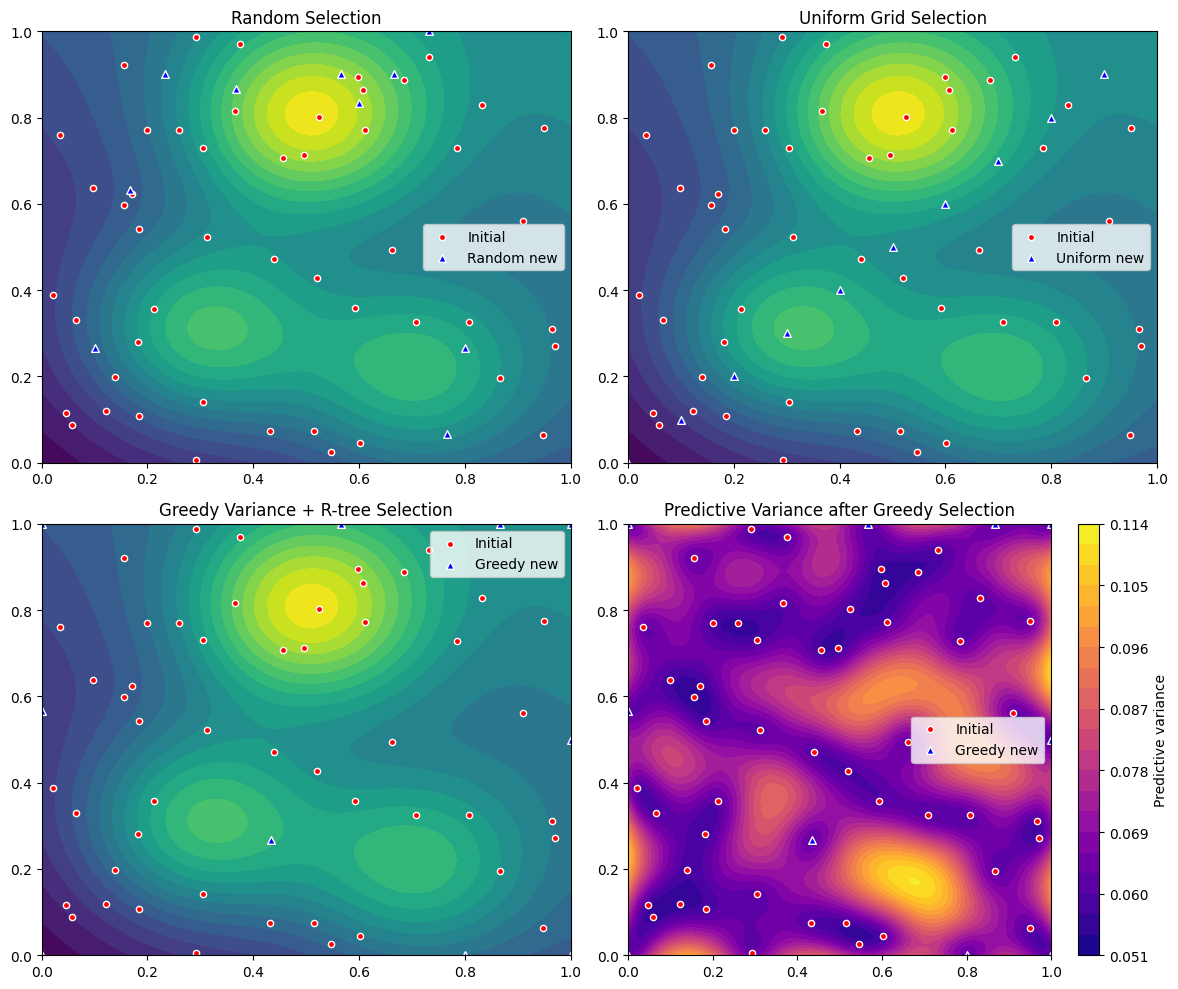

In [32]:
# Use the same repeat as in benchmarking (rep=0)
rep = 0
np.random.seed(RANDOM_SEED + rep)
init_x = np.random.uniform(0, 1, n_initial)
init_y = np.random.uniform(0, 1, n_initial)
init_z = true_field[np.searchsorted(x_grid, init_x), np.searchsorted(y_grid, init_y)] + np.random.normal(0, noise_std, n_initial)
init_coords = np.vstack([init_x, init_y]).T

# Random selection
random_indices = np.random.choice(len(candidate_coords), size=n_new, replace=False)
random_points = candidate_coords[random_indices]

# Uniform selection
step = int(len(candidate_coords) / n_new)
uniform_indices = np.arange(0, len(candidate_coords), step)[:n_new]
uniform_points = candidate_coords[uniform_indices]

# Greedy selection (re-run for consistency)
_, greedy_points, _ = greedy_variance_selection(init_coords, init_z, candidate_coords, test_coords, test_true, n_new)
greedy_points = np.array(greedy_points)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Random
ax = axes[0,0]
ax.contourf(X_grid, Y_grid, true_field, levels=20, cmap='viridis')
ax.scatter(init_x, init_y, c='red', s=20, edgecolor='white', label='Initial')
ax.scatter(random_points[:,0], random_points[:,1], c='blue', s=30, marker='^', edgecolor='white', label='Random new')
ax.set_title('Random Selection')
ax.legend()

# Uniform
ax = axes[0,1]
ax.contourf(X_grid, Y_grid, true_field, levels=20, cmap='viridis')
ax.scatter(init_x, init_y, c='red', s=20, edgecolor='white', label='Initial')
ax.scatter(uniform_points[:,0], uniform_points[:,1], c='blue', s=30, marker='^', edgecolor='white', label='Uniform new')
ax.set_title('Uniform Grid Selection')
ax.legend()

# Greedy placement
ax = axes[1,0]
ax.contourf(X_grid, Y_grid, true_field, levels=20, cmap='viridis')
ax.scatter(init_x, init_y, c='red', s=20, edgecolor='white', label='Initial')
ax.scatter(greedy_points[:,0], greedy_points[:,1], c='blue', s=30, marker='^', edgecolor='white', label='Greedy new')
ax.set_title('Greedy Variance + R-tree Selection')
ax.legend()

# Predictive variance after greedy selection
all_coords = np.vstack([init_coords, greedy_points])
all_z = np.hstack([init_z, true_field[np.searchsorted(x_grid, greedy_points[:,0]), np.searchsorted(y_grid, greedy_points[:,1])] + np.random.normal(0, noise_std, n_new)])
kernel = Matern(length_scale=0.1, nu=2.5) + WhiteKernel(noise_level=noise_std**2)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5)
gp.fit(all_coords, all_z)
_, variance = gp.predict(test_coords, return_std=True)
var_map = variance.reshape(X_grid.shape)

ax = axes[1,1]
im = ax.contourf(X_grid, Y_grid, var_map, levels=20, cmap='plasma')
ax.scatter(init_x, init_y, c='red', s=20, edgecolor='white', label='Initial')
ax.scatter(greedy_points[:,0], greedy_points[:,1], c='blue', s=30, marker='^', edgecolor='white', label='Greedy new')
plt.colorbar(im, ax=ax, label='Predictive variance')
ax.set_title('Predictive Variance after Greedy Selection')
ax.legend()

plt.tight_layout()
plt.savefig('spatial_comparison.png', dpi=300)
plt.show()

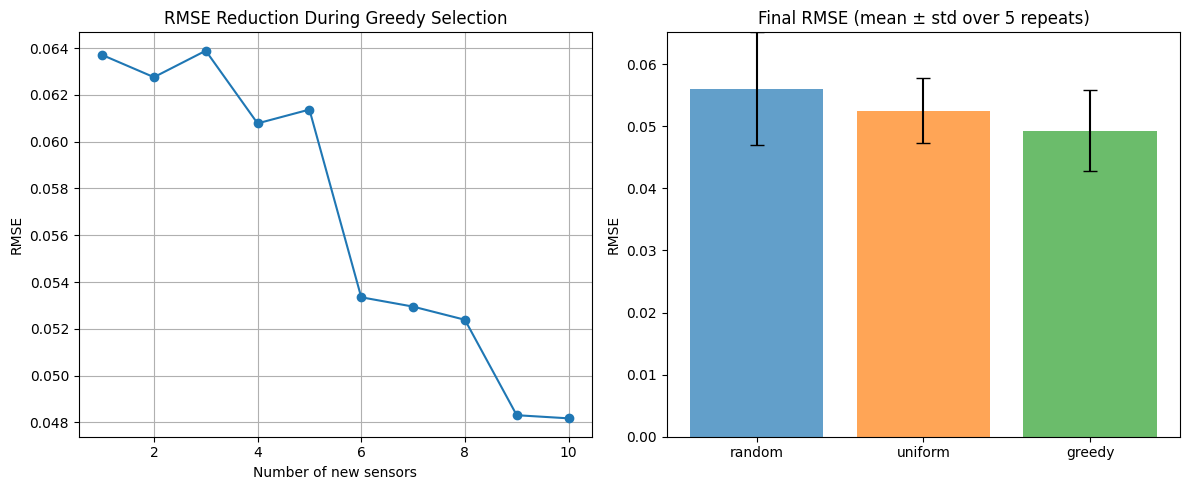

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# RMSE over steps (using the history stored from the first repeat)
ax1.plot(range(1, n_new+1), greedy_history, marker='o', label='Greedy')
ax1.set_xlabel('Number of new sensors')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE Reduction During Greedy Selection')
ax1.grid(True)

# Final RMSE comparison
methods = list(results.keys())
means = [results[m].mean() for m in methods]
stds = [results[m].std() for m in methods]
ax2.bar(methods, means, yerr=stds, capsize=5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_ylabel('RMSE')
ax2.set_title('Final RMSE (mean ± std over 5 repeats)')
ax2.set_ylim([0, max(means)+stds[0]])

plt.tight_layout()
plt.savefig('rmse_comparison.png', dpi=300)
plt.show()

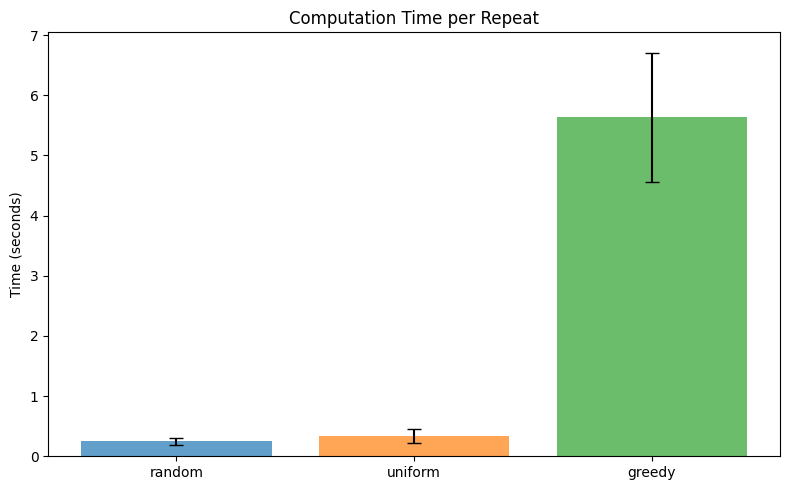

In [34]:
fig, ax = plt.subplots(figsize=(8,5))
means_time = [times[m].mean() for m in methods]
stds_time = [times[m].std() for m in methods]
ax.bar(methods, means_time, yerr=stds_time, capsize=5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Time (seconds)')
ax.set_title('Computation Time per Repeat')
plt.tight_layout()
plt.savefig('time_comparison.png', dpi=300)
plt.show()

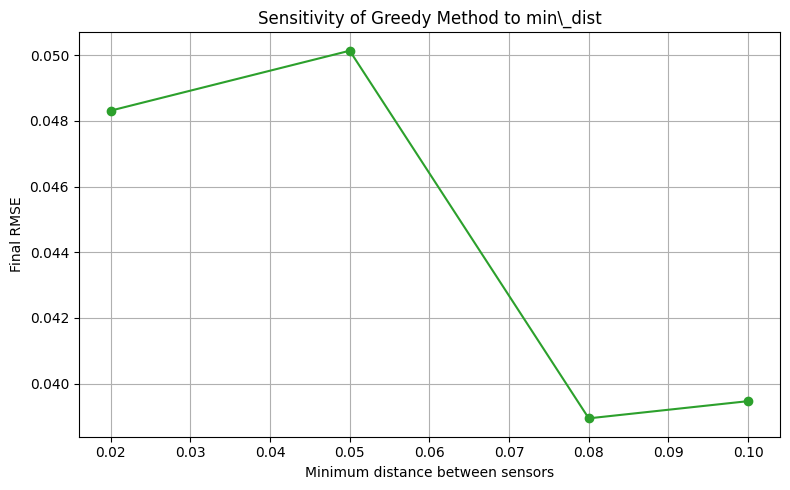

In [35]:
min_dist_values = [0.02, 0.05, 0.08, 0.10]
greedy_rmses = []
greedy_times = []

for min_d in min_dist_values:
    start = time.time()
    final_rmse, _, _ = greedy_variance_selection(init_coords, init_z, candidate_coords, test_coords, test_true, n_new, min_dist=min_d)
    greedy_times.append(time.time() - start)
    greedy_rmses.append(final_rmse)

plt.figure(figsize=(8,5))
plt.plot(min_dist_values, greedy_rmses, marker='o', linestyle='-', color='#2ca02c')
plt.xlabel('Minimum distance between sensors')
plt.ylabel('Final RMSE')
plt.title('Sensitivity of Greedy Method to min\_dist')
plt.grid(True)
plt.tight_layout()
plt.savefig('sensitivity_min_dist.png', dpi=300)
plt.show()

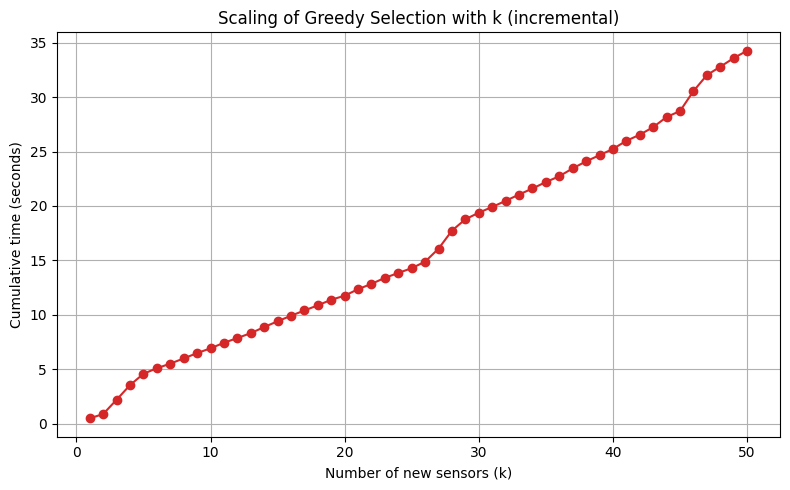

In [36]:
def greedy_variance_selection_with_timing(initial_coords, initial_z, candidate_coords, test_coords, test_true, k, min_dist=0.05):
    """
    Same as greedy_variance_selection but returns cumulative times per step.
    """
    current_coords = initial_coords.copy()
    current_z = initial_z.copy()
    selected_points = []
    rmse_history = []
    time_history = []
    start_total = time.time()

    for step in range(k):
        # 1. Train GP on current data
        kernel = Matern(length_scale=0.1, nu=2.5) + WhiteKernel(noise_level=noise_std**2)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5)
        gp.fit(current_coords, current_z)

        # 2. Predict variance at candidate locations
        _, variance = gp.predict(candidate_coords, return_std=True)
        variance = variance**2

        # 3. Build R-tree for existing sensors
        idx = index.Index()
        for i, (x, y) in enumerate(current_coords):
            idx.insert(i, (x, y, x, y))

        # 4. Filter candidates
        valid_candidates = []
        valid_vars = []
        for j, (x, y) in enumerate(candidate_coords):
            nearest = list(idx.intersection((x-min_dist, y-min_dist, x+min_dist, y+min_dist)))
            if not nearest:
                valid_candidates.append(j)
                valid_vars.append(variance[j])

        if not valid_candidates:
            valid_candidates = list(range(len(candidate_coords)))
            valid_vars = variance

        # 5. Priority queue
        heap = [(-valid_vars[i], valid_candidates[i]) for i in range(len(valid_vars))]
        heapq.heapify(heap)
        _, best_idx = heapq.heappop(heap)
        best_point = candidate_coords[best_idx]
        selected_points.append(best_point)

        # 6. Add new sensor
        best_z = true_field[np.searchsorted(x_grid, best_point[0]), np.searchsorted(y_grid, best_point[1])] + np.random.normal(0, noise_std)
        current_coords = np.vstack([current_coords, best_point])
        current_z = np.append(current_z, best_z)

        # 7. Evaluate RMSE (optional)
        rmse, _, _ = evaluate_sensors(current_coords, current_z, test_coords, test_true)
        rmse_history.append(rmse)

        # Record cumulative time
        time_history.append(time.time() - start_total)

    return rmse_history[-1], selected_points, rmse_history, time_history

# Run the timing version
k_max = 50
_, _, _, cumulative_times = greedy_variance_selection_with_timing(
    init_coords, init_z, candidate_coords, test_coords, test_true, k_max)

plt.figure(figsize=(8,5))
plt.plot(range(1, k_max+1), cumulative_times, marker='o', linestyle='-', color='#d62728')
plt.xlabel('Number of new sensors (k)')
plt.ylabel('Cumulative time (seconds)')
plt.title('Scaling of Greedy Selection with k (incremental)')
plt.grid(True)
plt.tight_layout()
plt.savefig('scaling_greedy.png', dpi=300)
plt.show()

# **Key Findings:**

> This study figures out the best places/locations to put new air quality sensors. It works like a detective:

    - It first builds a map of what we already know, then identifies the areas where we are most uncertain—the places where our guesses could be way off
    - Using clever shortcuts (like an address book for locations and a priority list), it quickly picks the spots that will give us the most useful new information.

**What this means for everyday people:**

    1. Saves money – Cities and environmental agencies don’t waste budget putting sensors where they aren’t needed.
    2. Better data – One can get a clearer picture/idea of pollution hotspots, helping officials take action where it matters most.
    3. Healthier communities/collaboration – With more accurate maps, people can make smarter decisions about where to live, play, and exercise, and policymakers can design targeted clean‑air policies.

**In a nutshell**:
    
    - This study finding is a smarter, cheaper way to keep an eye on the air we breathe, working as an applied Data Science, and Statistical study.